In [1]:
!uv sync

Resolved 17 packages in 22ms
Audited 16 packages in 4ms


In [ ]:
from mandrop.engine import make_step, feq_fn, ex_jnp, ey_jnp, opp, cs2

import jax
import jax.numpy as jnp
from jax import lax
import matplotlib.pyplot as plt

print(f"JAX {jax.__version__}, devices: {jax.devices()}")

In [ ]:
# Domain: 200 wide × 600 tall
Nx, Ny = 200, 600

# Droplet: 100 μm diameter → R = 50 lu (if dx = 1 μm)
R = 50.0

# Phase-field interface
W = 3.0                         # interface width (lattice units)
sigma = 0.01                    # surface tension (lattice units)
beta  = 3.0 * sigma / W
kappa = 6.0 * sigma * W

# Equal-density, equal-viscosity (simplest stable case)
rho0 = 1.0
nu   = 1.0 / 6.0               # kinematic viscosity
tau_f = 3.0 * nu + 0.5         # = 1.0

# Cahn-Hilliard mobility
Gamma_ch = 1.0
M_ch     = 0.01

# --- Physical-to-lattice pressure conversion ---
dx_phys = 1e-6
nu_phys = 7.68e-7
rho_phys = 1614.0
dt_phys = nu * dx_phys**2 / nu_phys
conv_p = rho_phys * (dx_phys / dt_phys)**2

# Capillary pressure ~ sigma/R_inlet ~ 0.01/40 ~ 0.00025
# Driving pressure = drho*cs2 = 0.001*0.333 = 0.00033 > capillary
drho = 0.001
rho_in  = rho0 + drho / 2.0
rho_out = rho0 - drho / 2.0

Nx_eff = Nx - 2
u_max_est = Nx_eff**2 * drho * cs2 / (8.0 * nu * Ny)
dp_cap = sigma / (0.4 * Nx / 2)
print(f"Domain: {Nx}×{Ny}")
print(f"Δρ={drho}, Poiseuille u_max ≈ {u_max_est:.4f} lu (Ma≈{u_max_est/0.577:.4f})")
print(f"Driving pressure: {drho*cs2:.5f}  vs  capillary: {dp_cap:.5f}  (ratio {drho*cs2/dp_cap:.1f}×)")

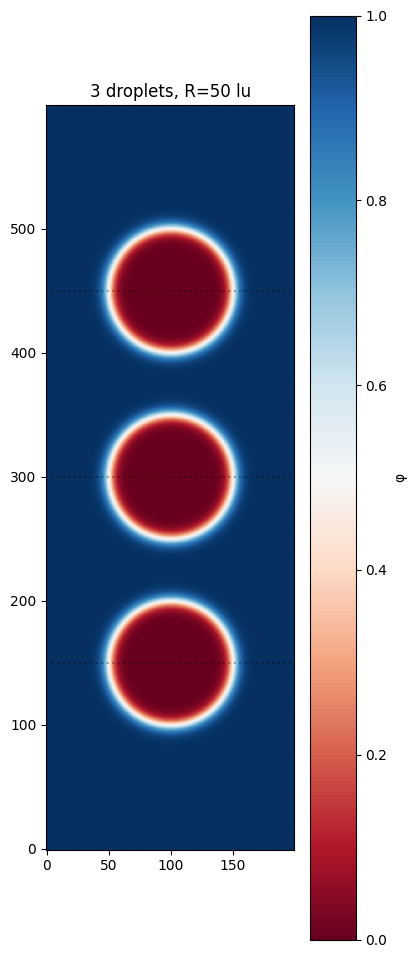

phi range: [0.000000, 1.000000]
Droplet centers (y): [150.0, 300.0, 450.0]
Gap between surfaces: 50 lu


In [137]:
x = jnp.arange(Nx, dtype=jnp.float64)
y = jnp.arange(Ny, dtype=jnp.float64)
X, Y = jnp.meshgrid(x, y, indexing='ij')

xc = Nx / 2.0

# 3 droplets in a vertical line, evenly spaced
droplet_centers = [150.0, 300.0, 450.0]  # y positions

phi0 = jnp.ones((Nx, Ny))  # start with oil everywhere
for yc_d in droplet_centers:
    r = jnp.sqrt((X - xc)**2 + (Y - yc_d)**2)
    phi_drop = 0.5 * (1.0 + jnp.tanh((r - R) / (2.0 * W)))
    phi0 = jnp.minimum(phi0, phi_drop)  # carve out each droplet

plt.figure(figsize=(4, 12))
plt.imshow(phi0.T, origin='lower', cmap='RdBu', vmin=0, vmax=1)
plt.colorbar(label='φ')
for yc_d in droplet_centers:
    plt.axhline(yc_d, color='k', ls=':', alpha=0.3)
plt.title(f'3 droplets, R={R:.0f} lu')
plt.show()

print(f"phi range: [{phi0.min():.6f}, {phi0.max():.6f}]")
print(f"Droplet centers (y): {droplet_centers}")
print(f"Gap between surfaces: {droplet_centers[1]-droplet_centers[0]-2*R:.0f} lu")

In [ ]:
# === Wall and Boundary Conditions ===
# Left/Right: bounce-back walls (no-slip)
# Top (y=Ny-1): inlet — center 40% water (phi=0), sides oil (phi=1)
# Bottom (y=0): outlet, pressure rho_out, zero-gradient phi

wall = jnp.zeros((Nx, Ny), dtype=bool)
wall = wall.at[0, :].set(True)     # left wall
wall = wall.at[-1, :].set(True)    # right wall

fluid = ~wall
interior = fluid & (jnp.arange(Ny)[None, :] > 0) & (jnp.arange(Ny)[None, :] < Ny - 1)

opp_jnp = jnp.array(opp)

# Water inlet strip: center 40% of channel width
inlet_width = int(0.4 * Nx)
inlet_x0 = Nx // 2 - inlet_width // 2
inlet_x1 = Nx // 2 + inlet_width // 2
inlet_water = jnp.zeros(Nx, dtype=bool)
inlet_water = inlet_water.at[inlet_x0:inlet_x1].set(True)
# phi at inlet: 0 where water, 1 where oil
phi_inlet = jnp.where(inlet_water, 0.0, 1.0)

step, apply_phi_walls = make_step(
    wall, fluid, interior, phi_inlet, opp_jnp,
    tau_f, beta, kappa, M_ch, rho_in, rho_out,
)

print(f"Channel: {Nx}×{Ny}, left/right walls, top=inlet, bottom=outlet")
print(f"Inlet: water (φ=0) at x=[{inlet_x0}, {inlet_x1}] ({inlet_width} lu = {100*inlet_width/Nx:.0f}% of width)")
print(f"Inlet: oil (φ=1) on sides")
print(f"rho_in={rho_in:.4f}, rho_out={rho_out:.4f}, Δρ={drho:.4f}")

In [141]:
rho_init = jnp.ones((Nx, Ny)) * rho0
ux0 = jnp.zeros((Nx, Ny))
uy0 = jnp.zeros((Nx, Ny))

f0 = feq_fn(rho_init, ux0, uy0)
phi0_box = apply_phi_walls(phi0)

print(f"3-droplet channel flow: {Nx}×{Ny}, inlet(top) → outlet(bottom)")
print(f"Δρ={drho}, expected Poiseuille u_max ≈ {u_max_est:.4f} lu")

state = (f0, phi0_box)
state = step(state)
print("JIT compiled.")

state = (f0, phi0_box)
chunk_size = 1000
n_chunks = 30  # 30k total steps

def scan_body(state, _):
    return step(state), None

import time
t0 = time.time()

print(f"\n{'step':>6} | {'phi_min':>10} {'phi_max':>10} | {'rho_min':>10} {'rho_max':>10} | {'max|u|':>10} | {'n_drops':>7} | {'phi@y=0':>10}")
print("-" * 100)

for chunk in range(n_chunks):
    state, _ = lax.scan(scan_body, state, None, length=chunk_size)
    f_c, phi_c = state
    f_c.block_until_ready()

    step_num = (chunk + 1) * chunk_size
    rho_c = jnp.sum(f_c, axis=-1)
    max_vel = jnp.max(jnp.sqrt((jnp.sum(f_c * ex_jnp, axis=-1) / rho_c)**2
                                + (jnp.sum(f_c * ey_jnp, axis=-1) / rho_c)**2))

    mask_c = (phi_c < 0.5).astype(jnp.float64) * interior
    n_droplet_cells = mask_c.sum()

    phi_at_outlet = phi_c[Nx//2, 0]

    print(f"{step_num:6d} | {phi_c.min():10.6f} {phi_c.max():10.6f} | {rho_c.min():10.6f} {rho_c.max():10.6f} | {max_vel:10.2e} | {n_droplet_cells:7.0f} | {phi_at_outlet:10.6f}")

    if jnp.isnan(phi_c).any() or jnp.isnan(f_c).any():
        print(f"  *** NaN detected at step {step_num}! ***")
        break

t1 = time.time()
f_final, phi_final = state
print(f"\nDone in {t1-t0:.1f}s ({n_chunks*chunk_size/(t1-t0):.0f} steps/s)")

3-droplet channel flow: 200×600, inlet(top) → outlet(bottom)
Δρ=0.001, expected Poiseuille u_max ≈ 0.0163 lu
JIT compiled.

  step |    phi_min    phi_max |    rho_min    rho_max |     max|u| | n_drops |    phi@y=0
----------------------------------------------------------------------------------------------------
  1000 |   0.000000   1.000000 |   0.999500   1.000793 |   6.74e-04 |   23521 |   0.998813
  2000 |   0.000000   1.000000 |   0.999500   1.000552 |   1.22e-03 |   23500 |   0.998193
  3000 |   0.000000   1.000000 |   0.999500   1.000809 |   1.75e-03 |   23542 |   0.997844
  4000 |   0.000000   1.000000 |   0.999478   1.000835 |   2.31e-03 |   23540 |   0.998128
  5000 |   0.000000   1.000000 |   0.999499   1.000981 |   2.83e-03 |   23516 |   0.998738
  6000 |   0.000000   1.000000 |   0.999498   1.000989 |   3.34e-03 |   23536 |   0.999174
  7000 |   0.000000   1.000000 |   0.999494   1.001025 |   3.83e-03 |   23523 |   0.999254
  8000 |   0.000000   1.000000 |   0.999490   1

In [142]:
rho_final = jnp.sum(f_final, axis=-1)
ux_final = jnp.sum(f_final * ex_jnp, axis=-1) / rho_final
uy_final = jnp.sum(f_final * ey_jnp, axis=-1) / rho_final
vel_mag = jnp.sqrt(ux_final**2 + uy_final**2)

mask = (phi_final < 0.5).astype(jnp.float64) * interior
n_droplet_cells = mask.sum()

print("=" * 50)
print(f"3-DROPLET CHANNEL — {n_chunks*chunk_size} STEPS")
print("=" * 50)
print(f"Max velocity:       {vel_mag.max():.4e} lu")
print(f"Droplet cells:      {n_droplet_cells:.0f}")
print(f"phi range:          [{phi_final.min():.6f}, {phi_final.max():.6f}]")
print(f"rho range:          [{rho_final.min():.6f}, {rho_final.max():.6f}]")

3-DROPLET CHANNEL — 30000 STEPS
Max velocity:       1.7510e-02 lu
Droplet cells:      15670
phi range:          [0.000000, 1.000000]
rho range:          [0.999047, 1.001118]


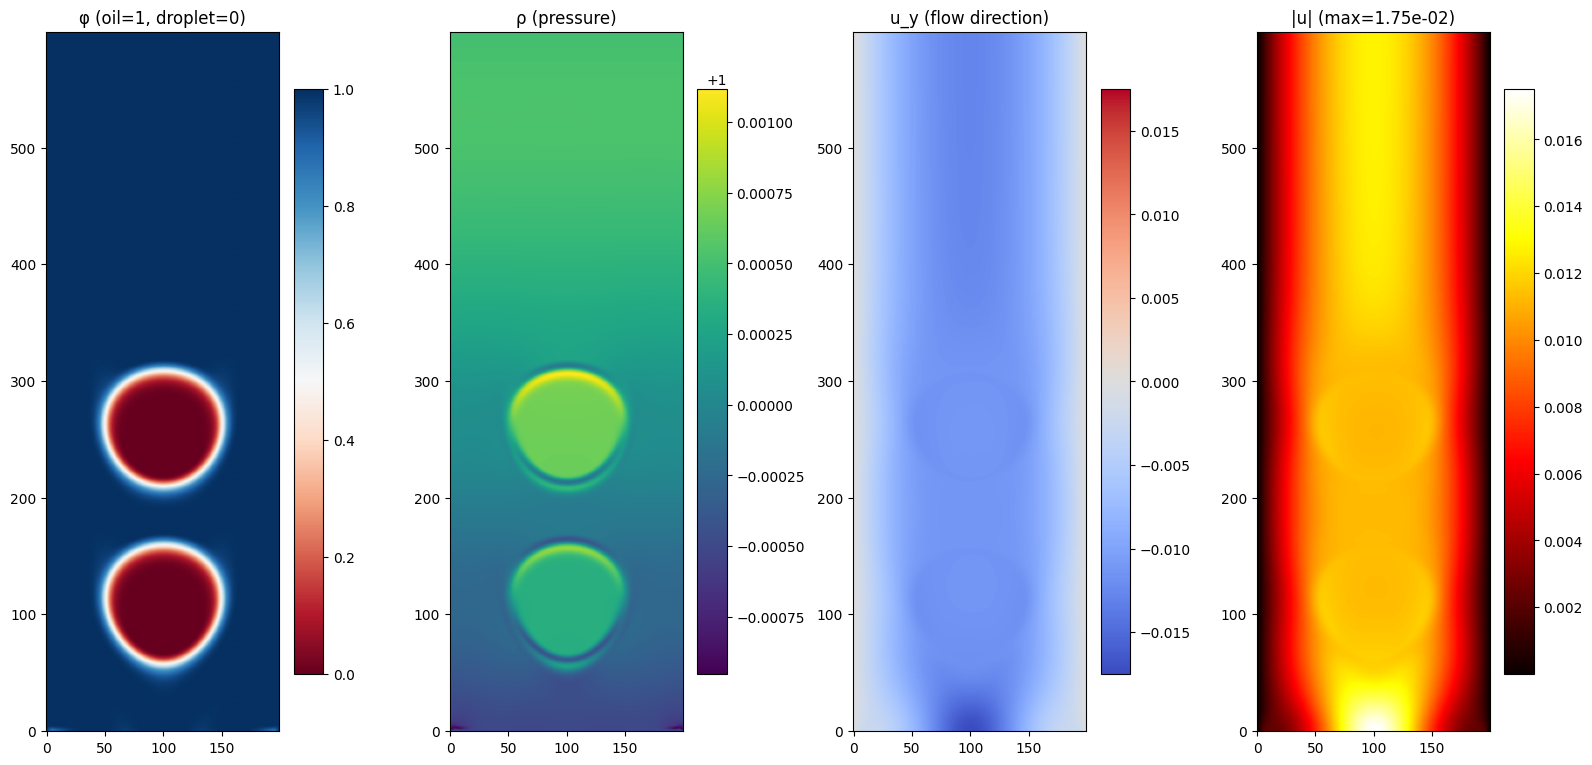

In [143]:
vel_mag = jnp.sqrt(ux_final**2 + uy_final**2)

fig, axes = plt.subplots(1, 4, figsize=(16, 12))

im0 = axes[0].imshow(phi_final.T, origin='lower', cmap='RdBu', vmin=0, vmax=1)
axes[0].set_title('φ (oil=1, droplet=0)')
plt.colorbar(im0, ax=axes[0], shrink=0.5)

im1 = axes[1].imshow(rho_final.T, origin='lower', cmap='viridis')
axes[1].set_title('ρ (pressure)')
plt.colorbar(im1, ax=axes[1], shrink=0.5)

im2 = axes[2].imshow(uy_final.T, origin='lower', cmap='coolwarm',
                       vmin=-vel_mag.max(), vmax=vel_mag.max())
axes[2].set_title('u_y (flow direction)')
plt.colorbar(im2, ax=axes[2], shrink=0.5)

im3 = axes[3].imshow(vel_mag.T, origin='lower', cmap='hot')
axes[3].set_title(f'|u| (max={vel_mag.max():.2e})')
plt.colorbar(im3, ax=axes[3], shrink=0.5)

for ax in axes:
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()